=== Dataset Head ===
   Customer_Age  Tenure_Months  Monthly_Charges  Total_Charges  Support_Calls  \
0            56             15        55.162269    1510.990030              5   
1            69             64        30.142083    1806.403317              7   
2            46             28        68.587176    4026.097294              9   
3            32             39        45.677657    1408.224165              3   
4            60             57        48.487290    1069.310720              4   

   Churn  
0      0  
1      0  
2      0  
3      0  
4      1  

=== Missing Values ===
Customer_Age       0
Tenure_Months      0
Monthly_Charges    0
Total_Charges      0
Support_Calls      0
Churn              0
dtype: int64

Logistic Regression Mean CV ROC-AUC: 0.3962
Random Forest Mean CV ROC-AUC: 0.4875

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       0

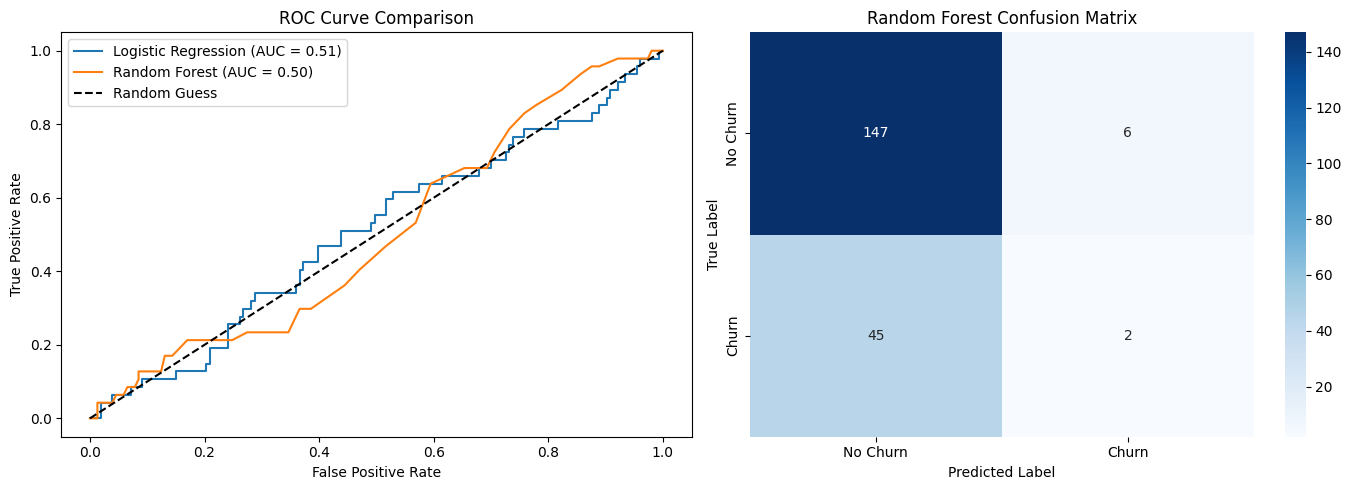

In [13]:
import warnings
warnings.filterwarnings('ignore')  # Suppresses all warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

# ==========================================
# STEP 1: SET UP AND DATA GENERATION
# ==========================================
np.random.seed(42)
n_samples = 1000

data = {
    'Customer_Age': np.random.randint(18, 70, size=n_samples),
    'Tenure_Months': np.random.randint(1, 72, size=n_samples),
    'Monthly_Charges': np.random.uniform(20, 120, size=n_samples),
    'Total_Charges': np.random.uniform(20, 5000, size=n_samples),
    'Support_Calls': np.random.randint(0, 10, size=n_samples),
    'Churn': np.random.choice([0, 1], size=n_samples, p=[0.75, 0.25]) # 25% Churn rate
}

df = pd.DataFrame(data)
print("=== Dataset Head ===")
print(df.head())

# ==========================================
# STEP 2: DATA PREPROCESSING
# ==========================================
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Split Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# STEP 3: MODEL TRAINING & CROSS-VALIDATION
# ==========================================
log_reg = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_cv = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
rf_cv = cross_val_score(rf_clf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"\nLogistic Regression Mean CV ROC-AUC: {log_reg_cv.mean():.4f}")
print(f"Random Forest Mean CV ROC-AUC: {rf_cv.mean():.4f}")

# Fit final models on full training set
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train, y_train)

# ==========================================
# STEP 4: MODEL EVALUATION & METRICS REPORT
# ==========================================
def evaluate_model(model, X_test_data, y_true, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1] 
    
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    
    print(f"\n=== {model_name} Classification Report ===")
    print(classification_report(y_true, y_pred))
    return metrics, y_prob

# Unpack both the dictionary metrics AND the probability arrays cleanly
log_metrics, log_prob = evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")
rf_metrics, rf_prob = evaluate_model(rf_clf, X_test, y_test, "Random Forest")

# Compare Metrics in a Table
performance_df = pd.DataFrame([log_metrics, rf_metrics], index=['Logistic Regression', 'Random Forest'])
print("\n=== Summary Performance Comparison ===")
print(performance_df.round(4))

# ==========================================
# STEP 5: VISUALIZATIONS
# ==========================================
# Set up plotting layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

axes[0].plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_metrics['ROC-AUC']:.2f})")
axes[0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Plot Random Forest Confusion Matrix as an example
cm = confusion_matrix(y_test, rf_clf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()